## Kliuev Dmitrii fifth dz

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("forest_dataset.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

clf = KNeighborsClassifier()

In [3]:
params = {
    'n_neighbors': list(range(1, 11)),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

In [4]:
clf_grid = GridSearchCV(
    estimator=clf,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

clf_grid.fit(X_train, y_train)

print(clf_grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


In [5]:
optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)

optimal_clf.fit(X_train, y_train)

pred_prob = optimal_clf.predict_proba(X_test)

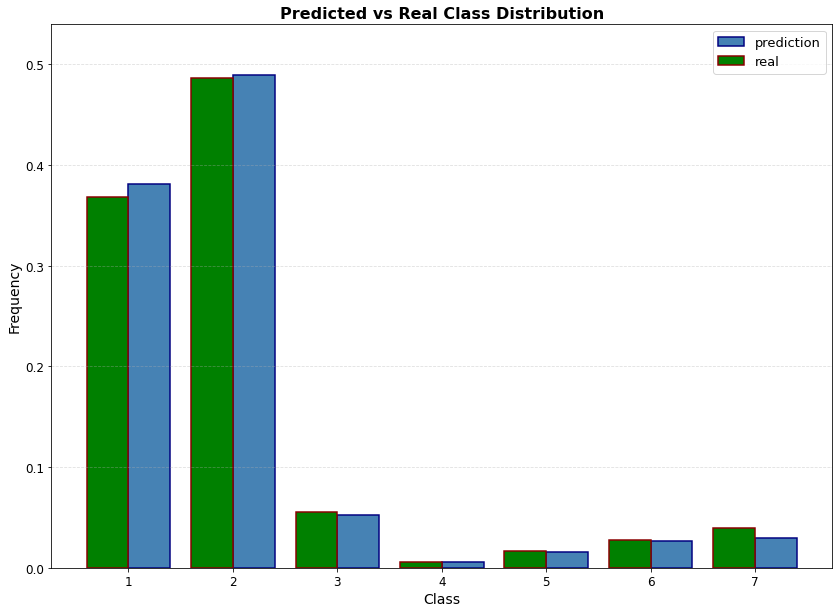

In [6]:
unique, freq = np.unique(y_test, return_counts=True)
freq = list(map(lambda x: x / len(y_test), freq))
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(14, 10))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label="prediction", color="steelblue", edgecolor="navy", linewidth=1.5)
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label="real", color="green", edgecolor="darkred", linewidth=1.5)
plt.ylim(0, 0.54)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Class", fontsize=14)
plt.xticks(range(1, 8), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=13)
plt.title("Predicted vs Real Class Distribution", fontsize=16, fontweight="bold")
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.show()

In [7]:
y_pred = optimal_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy is {accuracy}")

Test accuracy is 0.785


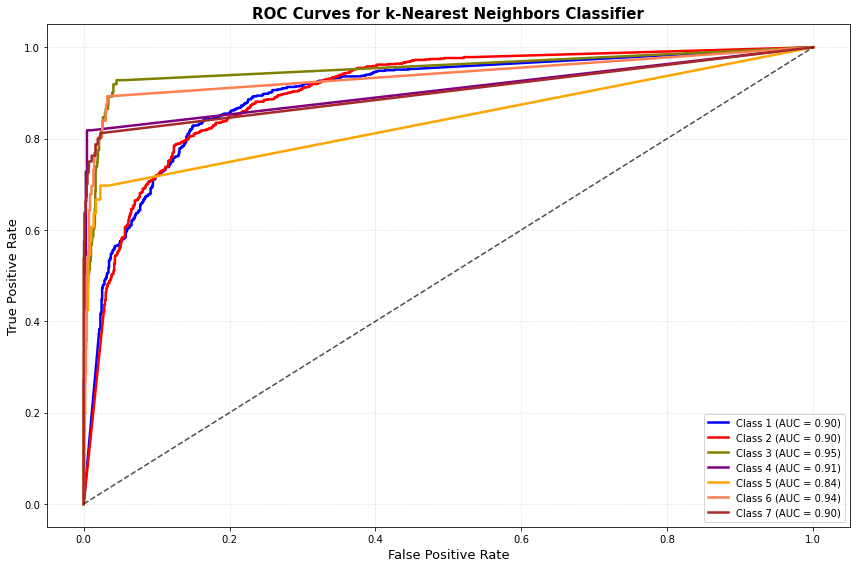

In [8]:
target_binarized = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6, 7])

false_positive = {}
true_positive = {}
area_under_curve = {}

for class_idx in range(7):
    false_positive[class_idx], true_positive[class_idx], _ = roc_curve(
        target_binarized[:, class_idx], 
        pred_prob[:, class_idx]
    )
    area_under_curve[class_idx] = auc(false_positive[class_idx], true_positive[class_idx])

colors = ["blue", "red", "olive", "purple", "orange", "coral", "brown"]

plt.figure(figsize=(12, 8))
for class_idx in range(7):
    plt.plot(
        false_positive[class_idx], 
        true_positive[class_idx], 
        linewidth=2.5, 
        color=colors[class_idx],
        label=f"Class {class_idx+1} (AUC = {area_under_curve[class_idx]:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, alpha=0.7)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curves for k-Nearest Neighbors Classifier", fontsize=15, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Выводы

**Плюсы kNN:**

- Алгоритм прост для понимания и не требует сложной настройки
- Нет необходимости в предварительном обучении модели
- Хорошо справляется с задачами, где связи между признаками нелинейны

**Минусы kNN:**

- При увеличении объема данных сильно возрастает время предсказания
- Требует много памяти для хранения всех обучающих примеров
- Результаты сильно зависят от того, какая метрика расстояния используется и сколько соседей выбрано
- Может давать ошибки при наличии выбросов или зашумленных данных

**Сравнение с логистической регрессией:**

На тестовой выборке точность kNN составила 0,785, в то время как логистическая регрессия обычно показывает на этом же дата сете примерно 0.65 - 0.7. Такая разница говорит о том, что в данных присутствуют нелинейные закономерности, которые kNN может выявлять, а линейные модели — нет. Значит kNN лучше
